In [2]:
# ============================================================
# BLOCK 1 — SETUP: LOAD DATASET, REBUILD FEATURES/TARGET/SPLIT
# Self-contained — does not depend on random_forest.ipynb being run in
# the same session. Rebuilds the exact same feature/label/split logic.
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_sample_weight

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# from google.colab import drive
# drive.mount('/content/drive')

DATA_DIR = "/content/drive/MyDrive/DAI_DSE/dataset"
TABULAR_PATH = f"{DATA_DIR}/dse_final_v3.csv"

df = pd.read_csv(TABULAR_PATH, parse_dates=["date"])
df = df.sort_values(["trading_code", "date"]).reset_index(drop=True)

ALL_FEATURES = [
    "daily_return","high_low_spread","intraday_volatility","volume_change_pct","price_gap",
    "rolling_5d_volatility","rolling_10d_momentum","ema_12",
    "macd","macd_signal","macd_hist","rsi_14","stoch_k","stoch_d","roc_10",
    "bb_width","atr_14","obv",
]

LABEL_MAP   = {0: 0, 1: 1, 3: 2}
CLASS_NAMES = {0: "Normal", 1: "High-Vol", 2: "Crash"}
CRASH_IDX   = 2

df["y"] = df["target_class"].map(LABEL_MAP)
assert df["y"].isnull().sum() == 0, "Unmapped target_class values found"

train_df = df[df["split"] == "train"].reset_index(drop=True)
test_df  = df[df["split"] == "test"].reset_index(drop=True)

X_train, y_train = train_df[ALL_FEATURES].values, train_df["y"].values.astype(int)
X_test,  y_test  = test_df[ALL_FEATURES].values,  test_df["y"].values.astype(int)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Test date range:", test_df["date"].min().date(), "->", test_df["date"].max().date())

Train: (630356, 18)  Test: (294590, 18)
Test date range: 2019-01-01 -> 2022-12-28


In [3]:
# ============================================================
# BLOCK 2 — FIT FINAL RANDOM FOREST, GENERATE TEST PREDICTIONS
# Uses the tuned hyperparameters identified in random_forest.ipynb's
# staged search. Update final_params_rf below if your tuned values
# differ from what's shown here.
# ============================================================
final_params_rf = dict(
    random_state=RANDOM_STATE, n_jobs=-1,
    n_estimators=250,        # <-- replace with your actual tuned value if different
    max_depth=25,            # <-- replace with your actual tuned value if different
    min_samples_split=5,     # <-- replace with your actual tuned value if different
    min_samples_leaf=2,      # <-- replace with your actual tuned value if different
    max_features="sqrt",     # <-- replace with your actual tuned value if different
    max_samples=0.8,         # <-- replace with your actual tuned value if different
)

sample_weight_full = compute_sample_weight("balanced", y_train)

final_model_rf = RandomForestClassifier(**final_params_rf)
final_model_rf.fit(X_train, y_train, sample_weight=sample_weight_full)

test_proba_rf = final_model_rf.predict_proba(X_test)
test_pred_rf  = test_proba_rf.argmax(axis=1)

print("Random Forest refit complete.")
print(f"Test-set crash-class predicted probability range: "
      f"{test_proba_rf[:, CRASH_IDX].min():.4f} to {test_proba_rf[:, CRASH_IDX].max():.4f}")

Random Forest refit complete.
Test-set crash-class predicted probability range: 0.0000 to 0.9256


In [4]:
# ============================================================
# BLOCK 3 — RECONSTRUCT RETURNS + BUILD TRADING SIGNAL
# "daily_return" in the final dataset is Winsorized + signed-log
# transformed (data_engineering.ipynb Block 9): x' = sign(x)*log(1+|x|).
# This inverts that transform to recover an approximate real percentage
# return. This is the CAPPED (Winsorized) series, not the true uncapped
# raw return — a conservative choice for backtesting, stated explicitly
# as a limitation.
# ============================================================
def inverse_signed_log(x_transformed):
    return np.sign(x_transformed) * (np.exp(np.abs(x_transformed)) - 1)

backtest_df = test_df[["trading_code", "date", "daily_return"]].copy()
backtest_df["approx_real_return_pct"] = inverse_signed_log(backtest_df["daily_return"].values)
backtest_df["crash_proba_rf"] = test_proba_rf[:, CRASH_IDX]
backtest_df = backtest_df.sort_values(["trading_code", "date"]).reset_index(drop=True)

print("Reconstructed approx. real return distribution (%):")
print(backtest_df["approx_real_return_pct"].describe())

# Risk-off rule: exit to cash when predicted crash probability exceeds the
# 95th percentile (top-5% most confident crash alerts), consistent with
# the "Precision@top-k alerts" framing already used in operational metrics.
CRASH_PROBA_THRESHOLD = backtest_df["crash_proba_rf"].quantile(0.95)
print(f"\nRisk-off threshold (95th pct. predicted crash probability): {CRASH_PROBA_THRESHOLD:.4f}")

backtest_df["position"] = np.where(backtest_df["crash_proba_rf"] > CRASH_PROBA_THRESHOLD, 0, 1)
pct_days_out = (backtest_df["position"] == 0).mean() * 100
print(f"Strategy is in cash on {pct_days_out:.2f}% of stock-days.")

# Day-t prediction targets t+1's realized state (per the t+1 label shift),
# so the position decided at t must apply to t+1's REALIZED return.
backtest_df["next_day_return_pct"] = (
    backtest_df.groupby("trading_code")["approx_real_return_pct"].shift(-1)
)
backtest_df = backtest_df.dropna(subset=["next_day_return_pct"]).reset_index(drop=True)

backtest_df["strategy_return_pct"] = backtest_df["position"] * backtest_df["next_day_return_pct"]
backtest_df["buyhold_return_pct"]  = backtest_df["next_day_return_pct"]

print(f"\nFinal backtest sample: {len(backtest_df):,} stock-day observations")

Reconstructed approx. real return distribution (%):
count    294590.000000
mean          0.049400
std           2.695283
min          -7.976058
25%          -1.290323
50%           0.000000
75%           0.892857
max           9.633911
Name: approx_real_return_pct, dtype: float64

Risk-off threshold (95th pct. predicted crash probability): 0.2276
Strategy is in cash on 5.00% of stock-days.

Final backtest sample: 294,269 stock-day observations


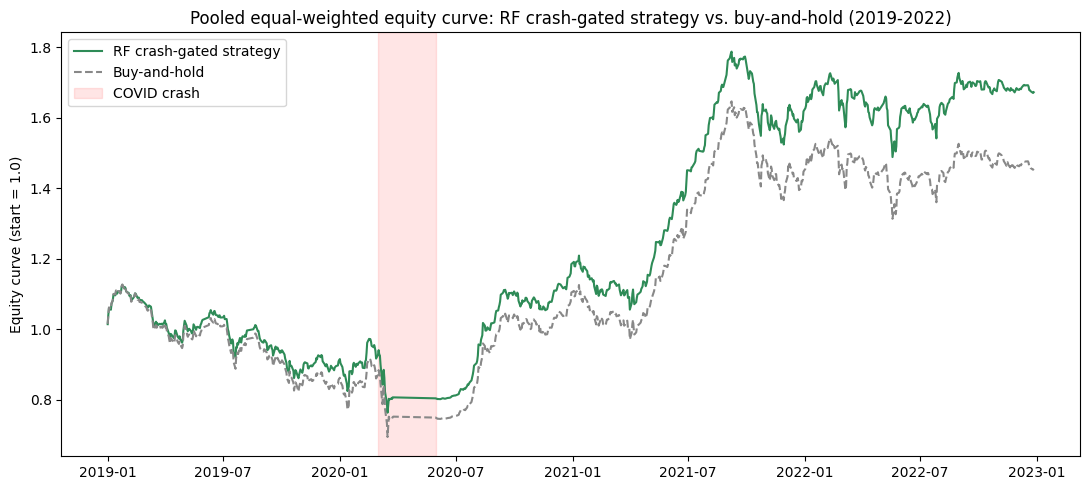

Final strategy equity : 1.6726
Final buy-hold equity : 1.4552


In [5]:
# ============================================================
# BLOCK 4 — POOLED, EQUAL-WEIGHTED PORTFOLIO CONSTRUCTION
# ============================================================
daily_portfolio = backtest_df.groupby("date").agg(
    strategy_return_pct=("strategy_return_pct", "mean"),
    buyhold_return_pct=("buyhold_return_pct", "mean"),
    n_stocks=("trading_code", "nunique"),
).sort_index()

daily_portfolio["strategy_return"] = daily_portfolio["strategy_return_pct"] / 100
daily_portfolio["buyhold_return"]  = daily_portfolio["buyhold_return_pct"] / 100

daily_portfolio["strategy_equity"] = (1 + daily_portfolio["strategy_return"]).cumprod()
daily_portfolio["buyhold_equity"]  = (1 + daily_portfolio["buyhold_return"]).cumprod()

plt.figure(figsize=(11, 5))
plt.plot(daily_portfolio.index, daily_portfolio["strategy_equity"], label="RF crash-gated strategy", color="#2e8b57")
plt.plot(daily_portfolio.index, daily_portfolio["buyhold_equity"], label="Buy-and-hold", color="#888888", linestyle="--")
plt.axvspan("2020-03-01", "2020-05-31", color="red", alpha=0.1, label="COVID crash")
plt.ylabel("Equity curve (start = 1.0)")
plt.title("Pooled equal-weighted equity curve: RF crash-gated strategy vs. buy-and-hold (2019-2022)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Final strategy equity : {daily_portfolio['strategy_equity'].iloc[-1]:.4f}")
print(f"Final buy-hold equity : {daily_portfolio['buyhold_equity'].iloc[-1]:.4f}")

In [6]:
# ============================================================
# BLOCK 5 — RISK-ADJUSTED PERFORMANCE METRICS
# ============================================================
TRADING_DAYS_PER_YEAR = 252

def compute_backtest_metrics(returns, equity_curve, label):
    total_return = equity_curve.iloc[-1] - 1
    n_days = len(returns)
    annualized_return = (1 + total_return) ** (TRADING_DAYS_PER_YEAR / n_days) - 1
    annualized_vol = returns.std() * np.sqrt(TRADING_DAYS_PER_YEAR)

    sharpe = (returns.mean() / returns.std()) * np.sqrt(TRADING_DAYS_PER_YEAR) if returns.std() > 0 else np.nan

    downside_returns = returns[returns < 0]
    downside_std = downside_returns.std()
    sortino = (returns.mean() / downside_std) * np.sqrt(TRADING_DAYS_PER_YEAR) if downside_std > 0 else np.nan

    running_max = equity_curve.cummax()
    drawdown = (equity_curve - running_max) / running_max
    max_drawdown = drawdown.min()

    win_rate = (returns > 0).mean()
    gross_profit = returns[returns > 0].sum()
    gross_loss = -returns[returns < 0].sum()
    profit_factor = gross_profit / gross_loss if gross_loss > 0 else np.nan

    return {
        "Strategy": label,
        "Total Return (%)": total_return * 100,
        "Annualized Return (%)": annualized_return * 100,
        "Annualized Volatility (%)": annualized_vol * 100,
        "Sharpe Ratio": sharpe,
        "Sortino Ratio": sortino,
        "Max Drawdown (%)": max_drawdown * 100,
        "Win Rate (%)": win_rate * 100,
        "Profit Factor": profit_factor,
    }

strategy_metrics = compute_backtest_metrics(
    daily_portfolio["strategy_return"], daily_portfolio["strategy_equity"], "RF Crash-Gated Strategy"
)
buyhold_metrics = compute_backtest_metrics(
    daily_portfolio["buyhold_return"], daily_portfolio["buyhold_equity"], "Buy-and-Hold"
)

metrics_df = pd.DataFrame([strategy_metrics, buyhold_metrics]).set_index("Strategy")
print(metrics_df.round(4))

                         Total Return (%)  Annualized Return (%)  \
Strategy                                                           
RF Crash-Gated Strategy           67.2588                15.0078   
Buy-and-Hold                      45.5229                10.7368   

                         Annualized Volatility (%)  Sharpe Ratio  \
Strategy                                                           
RF Crash-Gated Strategy                    16.3927        0.9351   
Buy-and-Hold                               18.1089        0.6536   

                         Sortino Ratio  Max Drawdown (%)  Win Rate (%)  \
Strategy                                                                 
RF Crash-Gated Strategy         1.3020          -32.2057       54.8004   
Buy-and-Hold                    0.9079          -38.4112       54.1532   

                         Profit Factor  
Strategy                                
RF Crash-Gated Strategy         1.1809  
Buy-and-Hold                    1.

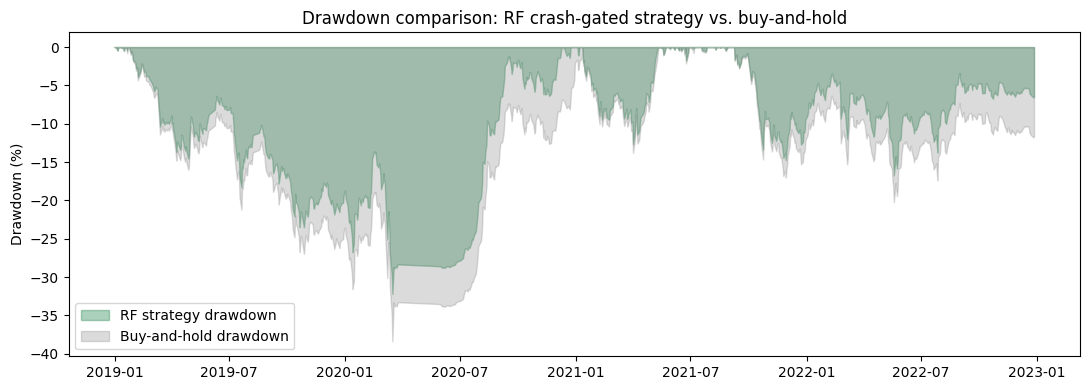

FINAL BACKTEST SUMMARY
                         Total Return (%)  Annualized Return (%)  \
Strategy                                                           
RF Crash-Gated Strategy           67.2588                15.0078   
Buy-and-Hold                      45.5229                10.7368   

                         Annualized Volatility (%)  Sharpe Ratio  \
Strategy                                                           
RF Crash-Gated Strategy                    16.3927        0.9351   
Buy-and-Hold                               18.1089        0.6536   

                         Sortino Ratio  Max Drawdown (%)  Win Rate (%)  \
Strategy                                                                 
RF Crash-Gated Strategy         1.3020          -32.2057       54.8004   
Buy-and-Hold                    0.9079          -38.4112       54.1532   

                         Profit Factor  
Strategy                                
RF Crash-Gated Strategy         1.1809  
Buy-and-Hol

In [7]:
# ============================================================
# BLOCK 6 — DRAWDOWN PLOT + FINAL SUMMARY
# ============================================================
running_max_strat = daily_portfolio["strategy_equity"].cummax()
drawdown_strat = (daily_portfolio["strategy_equity"] - running_max_strat) / running_max_strat

running_max_bh = daily_portfolio["buyhold_equity"].cummax()
drawdown_bh = (daily_portfolio["buyhold_equity"] - running_max_bh) / running_max_bh

plt.figure(figsize=(11, 4))
plt.fill_between(daily_portfolio.index, drawdown_strat * 100, 0, color="#2e8b57", alpha=0.4, label="RF strategy drawdown")
plt.fill_between(daily_portfolio.index, drawdown_bh * 100, 0, color="#888888", alpha=0.3, label="Buy-and-hold drawdown")
plt.ylabel("Drawdown (%)")
plt.title("Drawdown comparison: RF crash-gated strategy vs. buy-and-hold")
plt.legend()
plt.tight_layout()
plt.show()

print("="*70)
print("FINAL BACKTEST SUMMARY")
print("="*70)
print(metrics_df.round(4))
print(f"\nRisk-off threshold used: {CRASH_PROBA_THRESHOLD:.4f} (95th percentile predicted crash probability)")
print(f"Strategy in cash: {pct_days_out:.2f}% of stock-days")
print("\nNOTE: returns reconstructed from Winsorized (capped) daily_return feature —")
print("state this explicitly as a backtest limitation in the paper.")